<a href="https://colab.research.google.com/github/Sina-Haz/fastai-kaggle/blob/main/Vision_Classification_pt1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Computer Vision for Classification pt 1

Today we are working on vision based models for classification

This colab will cover the bare minimum to load a dataset, preprocess and augment it, and train over it with a finetuned model

Competition [link](https://www.kaggle.com/competitions/paddy-disease-classification/overview)

In order to do good we need to focus on:
1. Create effective validation set
2. Iterate with different models and changes to try and improve results

In [ ]:
! pip install -Uq fastkaggle


In [ ]:
from fastkaggle import *
import os

os.environ['KAGGLE_USERNAME'] = 'shazeghi'
os.environ['KAGGLE_KEY'] = '87607fda13bdf94dc22bbf70ef2383fb'

comp = 'paddy-disease-classification'
path = setup_comp(comp, install='')

In [ ]:
from fastai.vision.all import *

set_seed(42)

path.ls()

(#4) [Path('paddy-disease-classification/train_images'),Path('paddy-disease-classification/train.csv'),Path('paddy-disease-classification/sample_submission.csv'),Path('paddy-disease-classification/test_images')]

In [ ]:
# First we can look at the data
trn_path = path/'train_images'
test_path = path/'test_images'

files = get_image_files(trn_path) # gets all the images in a folder recursively (so under any subfolder too)

(640, 480) (480, 640)


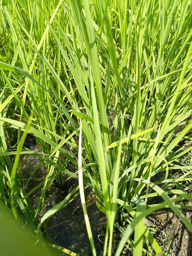

In [ ]:
img = PILImage.create(files[0])
print(img.shape, img.size) # For images convention is cols x rows, but for pytorch/ml libraries always rows x cols
img.to_thumb(256)

In [ ]:
# Let's check to see what sizes the images all are -> better to do this in parallel b/c decoding a jpeg takes a while
from fastcore.parallel import *

# Use this library to run a python function in parallel, first create the function
def f(img): return PILImage.create(img).size

sizes = parallel(f, files, n_workers=8) # stores all the return values of f iterating over files in a list
sizes


(#10407) [(480, 640),(480, 640),(480, 640),(480, 640),(480, 640),(480, 640),(480, 640),(480, 640),(480, 640),(480, 640),(480, 640),(480, 640),(480, 640),(480, 640),(480, 640),(480, 640),(480, 640),(480, 640),(480, 640),(480, 640)...]

In [ ]:
# Put sizes into a df/series so we can use value counts to see how many of each size there are
sizes = pd.Series(sizes)

sizes.value_counts() # so not all the same shape so need to do a bit of preprocessing to ensure uniform size

,count
"(480, 640)",10403
"(640, 480)",4


In [ ]:
path

Path('paddy-disease-classification')

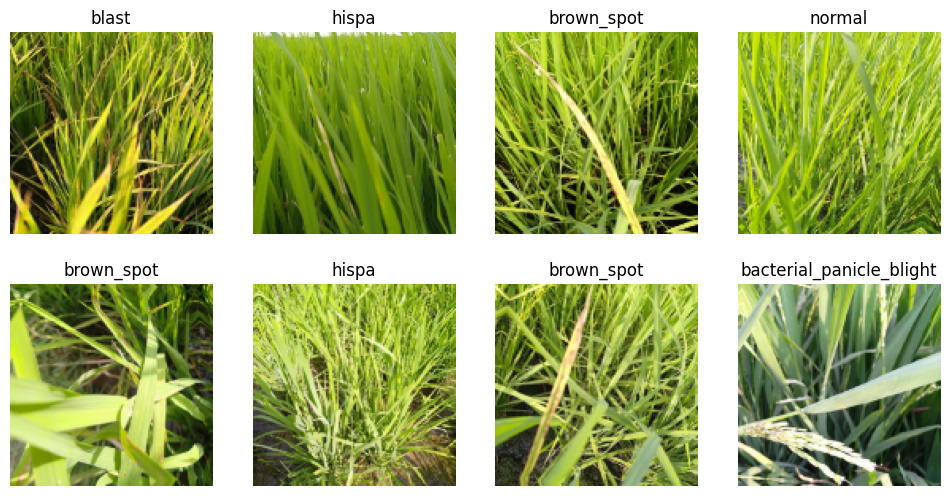

In [ ]:
# Load all the images using efficient fastai data loaders -> squish them to 480*480 for faster training
dls = ImageDataLoaders.from_folder(
    path=trn_path, valid_pct = 0.2, # b/c we don't have a defined validation subfolder (only test folder), need to input valid_pct
    item_tfms=Resize(480), # get uniform size to 480*480
    batch_tfms=aug_transforms(size=128, min_scale=0.75), # randomly resize by cropping down to 128*128
    bs=32
)

dls.show_batch(max_n=8)

### First Model

Look at this [link](https://www.kaggle.com/code/jhoward/the-best-vision-models-for-fine-tuning) for best vision models for finetuning

A good option for fast training and decent accuracy is a resnet type model -> here we go with resnet26d

The fastai learner class:
 - Infers based on dls the problem type (classification) and number of classes
 - Replaces last layers with custom classification head
 - Head includes linear layer which maps activations to logits -> from there logits inputted to softmax and argmax gives predicted class
 - During fine tuning, 1st epoch freezes all the weights except for head, afterwards default behavior is to unfreeze and train entire model with lower lr
 - Enables for easy integration of mixed precision and distributed training as well + can customize even at the low level model details

In [ ]:
model = vision_learner(dls, 'resnet26d', metrics=error_rate, path='.').to_fp16() # use mixed precision training

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/64.2M [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/usr/local/lib/python3.11/dist-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


SuggestedLRs(valley=0.0014454397605732083)

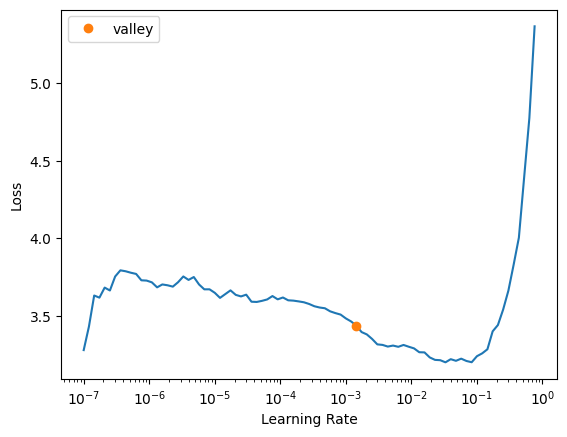

In [ ]:
# Lets see what a good learning rate is
model.lr_find() # looks like a good (but not very conservative) lr is 10^-2

In [ ]:
model.fine_tune(epochs=3, base_lr=1e-2)

/usr/local/lib/python3.11/dist-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/usr/local/lib/python3.11/dist-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


epoch,train_loss,valid_loss,error_rate,time
0,1.944865,1.444710,0.448823,01:04


epoch,train_loss,valid_loss,error_rate,time
0,1.272027,0.840549,0.282076,01:10
1,0.860979,0.504475,0.160980,01:06
2,0.597109,0.410178,0.123018,01:07


Ok cool we trained our first model, took a bit longer than expected but let's submit and see how it does

In [ ]:
sample = pd.read_csv(path/'sample_submission.csv')
sample.head() # sample is just image id in order along with label (which should be a string representing the disease)

,image_id,label
0,200001.jpg,NaN
1,200002.jpg,NaN
2,200003.jpg,NaN
3,200004.jpg,NaN
4,200005.jpg,NaN


In [ ]:
# First let's get our test files and sort them
tst_files = get_image_files(test_path).sorted() # returns an L object (list + extras) -> this has a sorted functionality

# Now add this to dls to get apply same data transforms and to make data inputtable to our model
tst_dls = dls.test_dl(tst_files)
tst_dls

In [ ]:
probs, _, idx = model.get_preds(dl=tst_dls, with_decoded=True) # get predictions, get_decoded argument means it applies argmax to probs to get predicted class
idx

tensor([7, 8, 8,  ..., 8, 3, 5])

In [ ]:
# We can then index into vocab to get the actual prediction
dls.vocab[idx][:5]

(#5) ['hispa','normal','normal','blast','blast']

In [ ]:
pred_sub = pd.DataFrame({'image_id': [f.name for f in tst_files], 'label': dls.vocab[idx]})
pred_sub.head()

,image_id,label
0,200001.jpg,hispa
1,200002.jpg,normal
2,200003.jpg,normal
3,200004.jpg,blast
4,200005.jpg,blast


In [ ]:
pred_sub.to_csv('subm.csv', index=False)
! head subm.csv

image_id,label
200001.jpg,hispa
200002.jpg,normal
200003.jpg,normal
200004.jpg,blast
200005.jpg,blast
200006.jpg,brown_spot
200007.jpg,dead_heart
200008.jpg,brown_spot
200009.jpg,hispa


In [ ]:
if not iskaggle:
  from kaggle import api
  # api.competition_submit_cli('subm.csv', 'first submission', comp) # commenting this out as now our first sub has been made

100%|██████████| 70.1k/70.1k [00:00<00:00, 105kB/s]


In [ ]:
! kaggle competitions submissions -c paddy-disease-classification

fileName  date                        description       status                     publicScore  privateScore  
--------  --------------------------  ----------------  -------------------------  -----------  ------------  
subm.csv  2025-04-07 02:36:42.840000  first submission  SubmissionStatus.COMPLETE  0.87274      0.87327       


Ok so with our first submission we got a score of .87 which puts us at about 520th place (out of 650) so definitely have a lot of room to improve
